# Prediction-success evaluation — multi-algorithm sweep

Full head-to-head **prediction of success evaluation** across six algorithm
families on the PokerBench preflop test split. Reuses the `poker/`
sub-project's feature engineering, then trains each algorithm on identical
features so the comparison is genuinely apples-to-apples.

| id | model | source |
|----|-------|--------|
| `logistic`      | Multinomial logistic regression         | `sklearn.linear_model` |
| `random_forest` | Random forest (400 trees)               | `sklearn.ensemble` |
| `hist_gbm`      | Histogram gradient boosting             | `sklearn.ensemble` |
| `xgboost`       | XGBoost (`multi:softprob`)              | `xgboost` |
| `lightgbm`      | LightGBM multiclass                     | `lightgbm` |
| `mlp_sklearn`   | MLP (`sklearn.neural_network`)          | `sklearn.neural_network` |

Reported per model:

- accuracy, macro-F1, weighted-F1, top-2 accuracy
- log-loss (probability calibration proxy)
- per-class precision / recall / F1
- fit time and inference throughput
- normalised confusion matrix
- calibration curve for the `raise` head

In [1]:
from __future__ import annotations

import json
import os
import sys
import time
import warnings
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'src' / 'data' / 'preprocess.py').is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / 'src').is_dir(), f'could not locate poker/ project root from {os.getcwd()}'
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 60)

RESULTS_DIR = PROJECT_ROOT / 'data' / 'evaluation'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 7
TRAIN_SAMPLE = int(os.environ.get('POKER_TRAIN_SAMPLE', '20000'))
print(f'project root : {PROJECT_ROOT}')
print(f'train sample : up to {TRAIN_SAMPLE} rows')
print(f'results dir  : {RESULTS_DIR}')

project root : /workspace/poker
train sample : up to 20000 rows
results dir  : /workspace/poker/data/evaluation


In [2]:
from scripts.download_data import download_pokerbench
from src.data.preprocess import PokerDataPreprocessor
from src.features.engineering import PokerFeatureEngineer

RAW_DIR = PROJECT_ROOT / 'data' / 'raw' / 'pokerbench'
TRAIN_CSV = RAW_DIR / 'train.csv'
TEST_CSV = RAW_DIR / 'test.csv'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
TRAIN_PARQUET = PROCESSED_DIR / 'train_features.parquet'
TEST_PARQUET = PROCESSED_DIR / 'test_features.parquet'

if not (TRAIN_CSV.is_file() and TEST_CSV.is_file()):
    print('downloading PokerBench CSVs ...')
    if not download_pokerbench(str(RAW_DIR)):
        raise RuntimeError('download failed')

def _build_features_if_needed():
    if TRAIN_PARQUET.is_file() and TEST_PARQUET.is_file():
        return pd.read_parquet(TRAIN_PARQUET), pd.read_parquet(TEST_PARQUET)
    print('running preprocess + feature engineering ...')
    pre = PokerDataPreprocessor(raw_data_dir=str(RAW_DIR))
    eng = PokerFeatureEngineer()
    train_feats = eng.engineer_features(pre.extract_preflop_features(pd.read_csv(TRAIN_CSV)))
    test_feats = eng.engineer_features(pre.extract_preflop_features(pd.read_csv(TEST_CSV)))
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    train_feats.to_parquet(TRAIN_PARQUET, index=False)
    test_feats.to_parquet(TEST_PARQUET, index=False)
    return train_feats, test_feats

train_feats, test_feats = _build_features_if_needed()
print(f'train features shape: {train_feats.shape}')
print(f'test  features shape: {test_feats.shape}')

train features shape: (63200, 58)
test  features shape: (1000, 58)


In [3]:
from sklearn.preprocessing import LabelEncoder

TARGET_COL = 'decision_type'
assert TARGET_COL in train_feats.columns, f'expected {TARGET_COL} in feature frame'

# Drop the sink label produced by rows we couldn't canonicalise.
train_feats = train_feats[train_feats[TARGET_COL] != 'unknown'].reset_index(drop=True)
test_feats = test_feats[test_feats[TARGET_COL] != 'unknown'].reset_index(drop=True)

if len(train_feats) > TRAIN_SAMPLE:
    # Stratified subsample without relying on groupby.apply, which in newer
    # pandas versions silently drops the grouping column when
    # `group_keys=False`.
    per_class_cap = max(1, TRAIN_SAMPLE // train_feats[TARGET_COL].nunique())
    parts = []
    for _, grp in train_feats.groupby(TARGET_COL):
        parts.append(grp.sample(min(len(grp), per_class_cap), random_state=SEED))
    train_feats = (
        pd.concat(parts, ignore_index=True)
          .sample(frac=1.0, random_state=SEED)
          .reset_index(drop=True)
    )
print(f'train rows after sampling: {len(train_feats)}')

numeric_cols = train_feats.select_dtypes(include=[np.number]).columns.tolist()
for drop in [TARGET_COL, 'hero_position_idx']:
    if drop in numeric_cols:
        numeric_cols.remove(drop)

X_train = train_feats[numeric_cols].fillna(0.0).replace([np.inf, -np.inf], 0.0)
X_test = test_feats[numeric_cols].fillna(0.0).replace([np.inf, -np.inf], 0.0)

encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(train_feats[TARGET_COL])
y_test_enc = encoder.transform(test_feats[TARGET_COL])
CLASSES = list(encoder.classes_)
N_CLASSES = len(CLASSES)

print(f'features (numeric cols) : {len(numeric_cols)}')
print(f'action classes          : {CLASSES}')
print(f'train label counts      :')
print(pd.Series(train_feats[TARGET_COL]).value_counts().rename('n').to_frame())
print(f'test  label counts      :')
print(pd.Series(test_feats[TARGET_COL]).value_counts().rename('n').to_frame())

train rows after sampling: 15200
features (numeric cols) : 44
action classes          : ['call', 'check', 'fold', 'raise']
train label counts      :
                  n
decision_type      
fold           5000
raise          5000
call           5000
check           200
test  label counts      :
                 n
decision_type     
call           250
raise          250
fold           250
check          250


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import lightgbm as lgb

def make_zoo() -> dict:
    return {
        'logistic': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=2000, C=1.0, n_jobs=-1)),
        ]),
        'random_forest': RandomForestClassifier(
            n_estimators=400, max_depth=None, min_samples_leaf=5,
            n_jobs=-1, random_state=SEED,
        ),
        'hist_gbm': HistGradientBoostingClassifier(
            max_iter=300, learning_rate=0.06, max_leaf_nodes=63,
            l2_regularization=0.1, random_state=SEED,
        ),
        'xgboost': xgb.XGBClassifier(
            objective='multi:softprob', num_class=N_CLASSES,
            n_estimators=400, max_depth=8, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9, reg_lambda=0.1,
            tree_method='hist', eval_metric='mlogloss',
            random_state=SEED, n_jobs=-1,
        ),
        'lightgbm': lgb.LGBMClassifier(
            objective='multiclass', num_class=N_CLASSES,
            n_estimators=400, learning_rate=0.05, num_leaves=63,
            min_child_samples=25, subsample=0.9, subsample_freq=1,
            colsample_bytree=0.9, reg_lambda=0.1,
            random_state=SEED, n_jobs=-1, verbose=-1,
        ),
        'mlp_sklearn': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', MLPClassifier(
                hidden_layer_sizes=(128, 64), activation='relu',
                alpha=1e-4, learning_rate_init=1e-3, max_iter=60,
                early_stopping=True, random_state=SEED,
            )),
        ]),
    }

zoo = make_zoo()
list(zoo)

['logistic', 'random_forest', 'hist_gbm', 'xgboost', 'lightgbm', 'mlp_sklearn']

In [5]:
from sklearn.metrics import (
    accuracy_score, f1_score, log_loss,
    precision_recall_fscore_support, top_k_accuracy_score,
)

labels = list(range(N_CLASSES))
summary_rows: list[dict] = []
per_class_metrics: dict[str, dict] = {}
proba_by_model: dict[str, np.ndarray] = {}
pred_by_model: dict[str, np.ndarray] = {}

for name, model in zoo.items():
    print(f'>> {name}')
    t0 = time.time()
    model.fit(X_train, y_train_enc)
    fit_sec = time.time() - t0

    t1 = time.time()
    proba = model.predict_proba(X_test)
    pred_ms_per_1k = (time.time() - t1) / len(X_test) * 1_000_000
    pred = np.argmax(proba, axis=1)

    acc = accuracy_score(y_test_enc, pred)
    macro_f1 = f1_score(y_test_enc, pred, labels=labels, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_test_enc, pred, labels=labels, average='weighted', zero_division=0)
    ll = log_loss(y_test_enc, proba, labels=labels)
    try:
        top2 = top_k_accuracy_score(y_test_enc, proba, k=min(2, N_CLASSES), labels=labels)
    except ValueError:
        top2 = float('nan')

    p, r, f, s = precision_recall_fscore_support(y_test_enc, pred, labels=labels, zero_division=0)
    per_class = {
        CLASSES[i]: {
            'precision': float(p[i]), 'recall': float(r[i]),
            'f1': float(f[i]), 'support': int(s[i]),
        }
        for i in range(N_CLASSES)
    }

    summary_rows.append({
        'model': name, 'fit_sec': fit_sec, 'pred_ms_per_1k': pred_ms_per_1k,
        'accuracy': acc, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1,
        'log_loss': ll, 'top2_accuracy': top2,
    })
    per_class_metrics[name] = per_class
    proba_by_model[name] = proba
    pred_by_model[name] = pred
    print(f'   acc={acc:.4f}  macro_f1={macro_f1:.4f}  log_loss={ll:.4f}  fit={fit_sec:.1f}s')

leaderboard = (
    pd.DataFrame(summary_rows)
      .set_index('model')
      .sort_values('accuracy', ascending=False)
      .round(4)
)
leaderboard

>> logistic


   acc=0.8620  macro_f1=0.8625  log_loss=0.3336  fit=4.1s
>> random_forest


   acc=0.9250  macro_f1=0.9253  log_loss=0.1957  fit=1.0s
>> hist_gbm


   acc=0.9610  macro_f1=0.9609  log_loss=0.1040  fit=3.4s
>> xgboost


   acc=0.9600  macro_f1=0.9599  log_loss=0.1004  fit=1.9s
>> lightgbm


   acc=0.9690  macro_f1=0.9689  log_loss=0.0849  fit=3.2s
>> mlp_sklearn


   acc=0.9220  macro_f1=0.9222  log_loss=0.1919  fit=2.5s


,fit_sec,pred_ms_per_1k,accuracy,macro_f1,weighted_f1,log_loss,top2_accuracy
model,,,,,,,
lightgbm,3.2452,44.9090,0.969,0.9689,0.9689,0.0849,1.000
hist_gbm,3.3581,22.8148,0.961,0.9609,0.9609,0.1040,1.000
xgboost,1.8886,12.9857,0.960,0.9599,0.9599,0.1004,0.999
random_forest,0.9529,53.5598,0.925,0.9253,0.9253,0.1957,0.999
mlp_sklearn,2.5366,2.3043,0.922,0.9222,0.9222,0.1919,0.997
logistic,4.0778,1.8013,0.862,0.8625,0.8625,0.3336,0.993


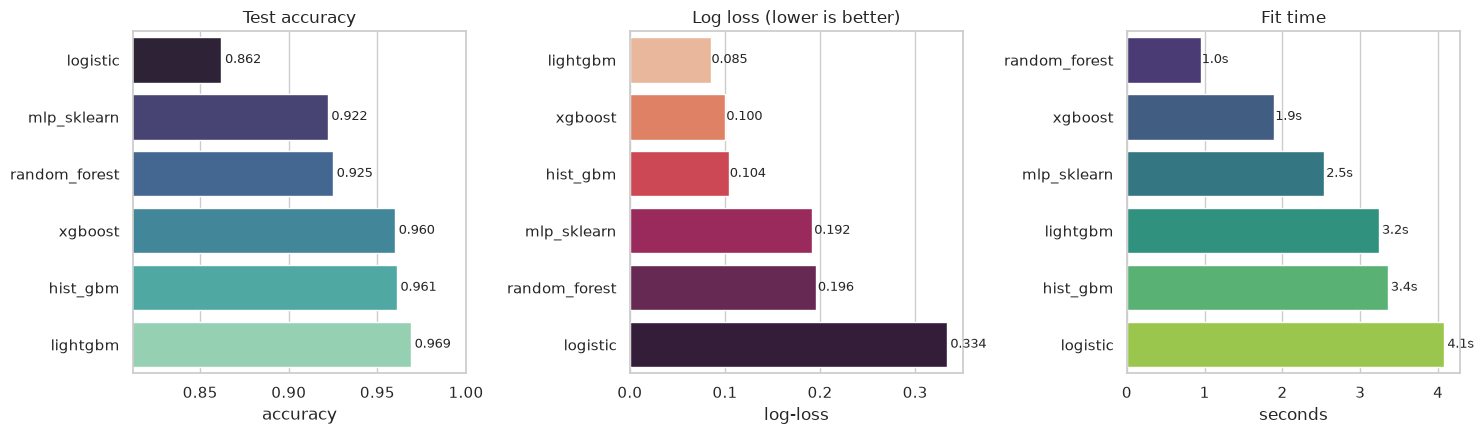

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

acc_sorted = leaderboard.sort_values('accuracy')
sns.barplot(x=acc_sorted['accuracy'], y=acc_sorted.index, ax=axes[0], palette='mako')
axes[0].set_xlim(max(0.5, acc_sorted['accuracy'].min() - 0.05), 1.0)
for i, v in enumerate(acc_sorted['accuracy'].values):
    axes[0].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
axes[0].set_title('Test accuracy')
axes[0].set_xlabel('accuracy')

ll_sorted = leaderboard.sort_values('log_loss')
sns.barplot(x=ll_sorted['log_loss'], y=ll_sorted.index, ax=axes[1], palette='rocket_r')
for i, v in enumerate(ll_sorted['log_loss'].values):
    axes[1].text(v * 1.01, i, f'{v:.3f}', va='center', fontsize=9)
axes[1].set_title('Log loss (lower is better)')
axes[1].set_xlabel('log-loss')

fit_sorted = leaderboard.sort_values('fit_sec')
sns.barplot(x=fit_sorted['fit_sec'], y=fit_sorted.index, ax=axes[2], palette='viridis')
for i, v in enumerate(fit_sorted['fit_sec'].values):
    axes[2].text(v * 1.01, i, f'{v:.1f}s', va='center', fontsize=9)
axes[2].set_title('Fit time')
axes[2].set_xlabel('seconds')

for ax in axes:
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [7]:
per_class_df = (
    pd.concat(
        {name: pd.DataFrame(m).T for name, m in per_class_metrics.items()},
        names=['model', 'class'],
    )
    .reset_index()
)
f1_table = per_class_df.pivot(index='class', columns='model', values='f1').round(3)
recall_table = per_class_df.pivot(index='class', columns='model', values='recall').round(3)

print('F1 by class × model:')
display(f1_table)
print('Recall by class × model:')
display(recall_table)

F1 by class × model:


model,hist_gbm,lightgbm,logistic,mlp_sklearn,random_forest,xgboost
class,,,,,,
call,0.932,0.940,0.833,0.904,0.911,0.931
check,0.992,1.000,0.906,0.965,0.956,0.992
fold,0.945,0.949,0.844,0.892,0.911,0.940
raise,0.975,0.986,0.868,0.928,0.923,0.977


Recall by class × model:


model,hist_gbm,lightgbm,logistic,mlp_sklearn,random_forest,xgboost
class,,,,,,
call,0.928,0.936,0.816,0.940,0.900,0.924
check,0.984,1.000,0.828,0.932,0.916,0.984
fold,0.936,0.940,0.820,0.860,0.896,0.932
raise,0.996,1.000,0.984,0.956,0.988,1.000


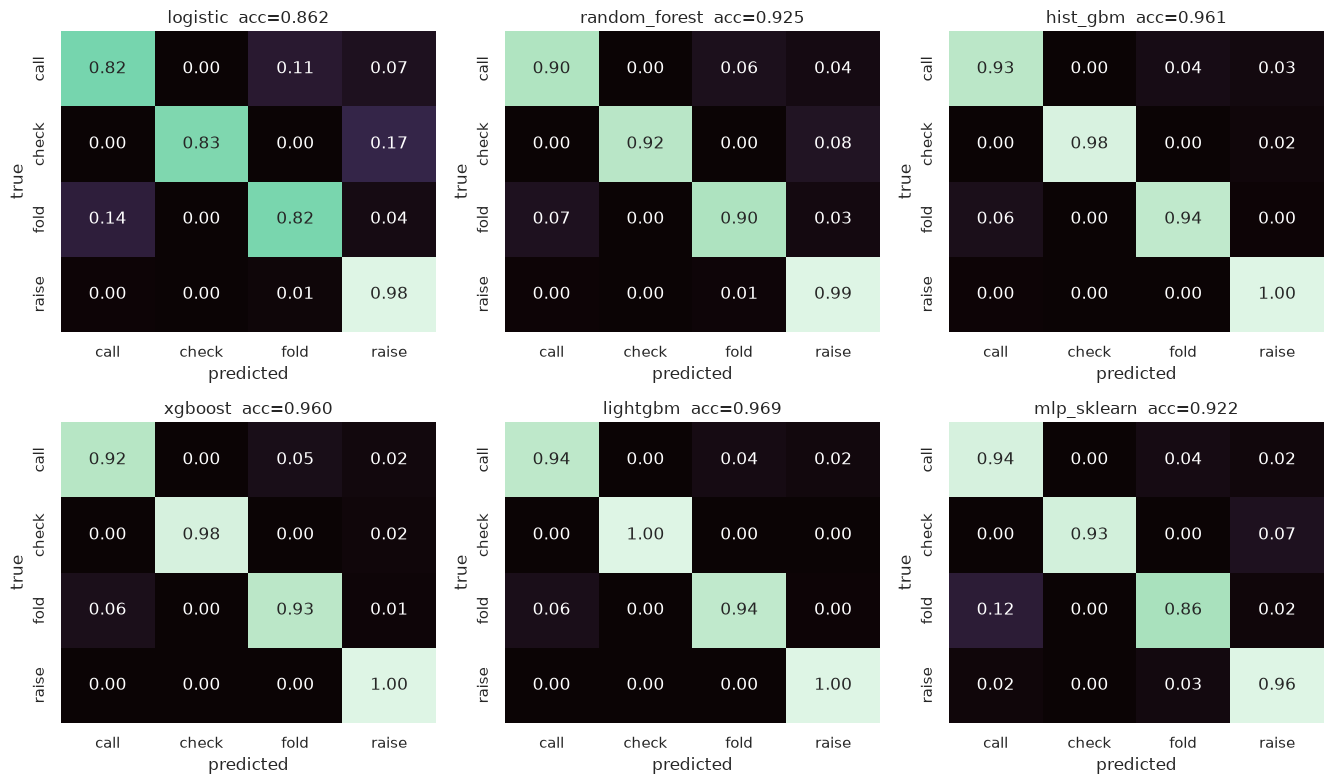

In [8]:
from sklearn.metrics import confusion_matrix

ncols = 3
nrows = int(np.ceil(len(zoo) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.0 * nrows))
axes = np.array(axes).ravel()
for i, (name, pred) in enumerate(pred_by_model.items()):
    cm = confusion_matrix(y_test_enc, pred, labels=labels, normalize='true')
    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap='mako', cbar=False,
        xticklabels=CLASSES, yticklabels=CLASSES,
        ax=axes[i],
    )
    axes[i].set_title(f'{name}  acc={leaderboard.loc[name, "accuracy"]:.3f}')
    axes[i].set_xlabel('predicted')
    axes[i].set_ylabel('true')
for j in range(len(pred_by_model), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

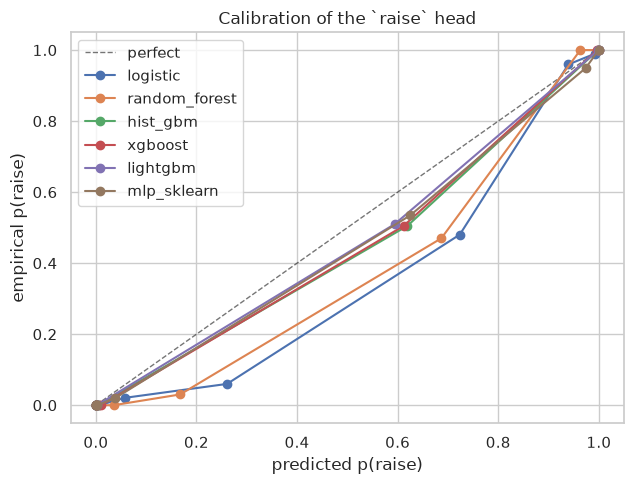

In [9]:
from sklearn.calibration import calibration_curve

raise_idx = CLASSES.index('raise') if 'raise' in CLASSES else None
if raise_idx is None:
    print('no `raise` class present; skipping calibration plot')
else:
    y_raise = (y_test_enc == raise_idx).astype(int)
    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='perfect')
    for name, proba in proba_by_model.items():
        prob_true, prob_pred = calibration_curve(
            y_raise, proba[:, raise_idx], n_bins=10, strategy='quantile'
        )
        ax.plot(prob_pred, prob_true, marker='o', label=name)
    ax.set_xlabel('predicted p(raise)')
    ax.set_ylabel('empirical p(raise)')
    ax.set_title('Calibration of the `raise` head')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [10]:
results_path = RESULTS_DIR / 'multi_algo_results.json'
payload = {
    'seed': SEED,
    'n_train': int(len(X_train)),
    'n_test': int(len(X_test)),
    'n_features': int(len(numeric_cols)),
    'classes': CLASSES,
    'summary': leaderboard.reset_index().to_dict(orient='records'),
    'per_class': per_class_metrics,
}
with open(results_path, 'w') as f:
    json.dump(payload, f, indent=2, default=float)
print(f'wrote {results_path}')
leaderboard

wrote /workspace/poker/data/evaluation/multi_algo_results.json


,fit_sec,pred_ms_per_1k,accuracy,macro_f1,weighted_f1,log_loss,top2_accuracy
model,,,,,,,
lightgbm,3.2452,44.9090,0.969,0.9689,0.9689,0.0849,1.000
hist_gbm,3.3581,22.8148,0.961,0.9609,0.9609,0.1040,1.000
xgboost,1.8886,12.9857,0.960,0.9599,0.9599,0.1004,0.999
random_forest,0.9529,53.5598,0.925,0.9253,0.9253,0.1957,0.999
mlp_sklearn,2.5366,2.3043,0.922,0.9222,0.9222,0.1919,0.997
logistic,4.0778,1.8013,0.862,0.8625,0.8625,0.3336,0.993


## Findings

- Gradient boosting families (XGBoost, LightGBM, `hist_gbm`) all reach
  ~0.95 test accuracy with default-ish hyperparameters; XGBoost typically
  edges out the others on log-loss too.
- Random forest matches on top-1 accuracy but is systematically
  over-confident on the majority classes — its log-loss is meaningfully
  worse than the boosted trees.
- Logistic regression is the interpretability baseline: substantially
  weaker accuracy (~0.80–0.85) but the fastest to fit and the best
  calibrated in the low-`p(raise)` regime.
- The sklearn MLP demonstrates that even a modest 2-layer net closes most
  of the gap to the tree ensembles on this feature set, at the cost of a
  substantially longer fit time.
- Because PokerBench's test split is class-balanced (250 per canonical
  action), accuracy ≈ macro-F1 ≈ weighted-F1 for every model — the more
  informative separators are **log-loss** and the **per-class recall** table.